# Estimating Expected Probability of Default

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, recall_score, precision_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

## 2. Import data

In [3]:
# Load the data
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/CIR_CBI_data_for_est_PDs.dta"  # Use your file path here
raw_data = pd.read_stata(file_path)

# Display basic information about the dataset
raw_data.head()

,firmID,year,cnae2009Division,firm_size,postal_code,I_overdue,LT_debt_sh,l_age,lag_l_Assets,lag_liq_ratio,...,lag_ROA,lag_EBITDA_A,lag_inventory_sales,lag_receiv_sales,lag_current_ratio,tag,exclude,housing,NACE_grouped,low_q
0,27,2001,55,Medium,28014.0,0,0.805376,4.521789,9.899379,0.051765,...,0.079094,0.165816,0.008892,0.670910,2.589375,NaN,0,0,Hospitality & Entertainment,0
1,27,2002,55,Medium,28014.0,0,0.802936,4.532599,10.008686,0.061274,...,0.074545,0.157471,0.006592,0.912183,2.629214,NaN,0,0,Hospitality & Entertainment,0
2,27,2003,55,Medium,28014.0,0,0.932781,4.543295,9.988968,0.466521,...,0.077117,0.143958,0.001067,0.139008,3.187269,NaN,0,0,Hospitality & Entertainment,0
3,50,2004,71,Small,28020.0,0,1.000000,1.791759,7.400620,0.130727,...,-0.033598,-0.043372,0.000000,0.175666,3.773196,NaN,0,0,Professional & Admin Services,0
4,50,2005,71,Small,28020.0,0,1.000000,1.945910,7.315884,0.085771,...,-0.286569,-0.036569,0.000000,0.126744,2.542222,NaN,0,0,Professional & Admin Services,0


In [6]:
# Group by sector and aggregate counts and sum of events
summary = raw_data.groupby(['NACE_grouped']).agg(
    observations = ('I_overdue', 'size'),  # Total number of rows in each group
    events = ('I_overdue', 'sum')         # Sum of 'I_overdue' in each group
).reset_index()
summary['event_rate'] = summary['events'] / summary['observations']
print('Loan delinquencies by sector')
print(summary)

Loan delinquencies by sector
                    NACE_grouped  observations  events  event_rate
0                 Primary sector        220724    4391    0.019894
1                  Manufacturing        907789   16735    0.018435
2                      Utilities         93995    1190    0.012660
3                   Construction       1260510   53409    0.042371
4       Wholesale & Retail Trade       1787466   27753    0.015526
5                 Transportation         80405    1252    0.015571
6    Hospitality & Entertainment        540178   11423    0.021147
7                            ICT        172151    2376    0.013802
8                    Real Estate        714185   19569    0.027400
9  Professional & Admin Services        913427   13813    0.015122


In [7]:
# Group by firm_size and NACE_grouped and aggregate counts and sum of events
summary = raw_data.groupby(['NACE_grouped','firm_size']).agg(
    observations = ('I_overdue', 'size'),  # Total number of rows in each group
    events = ('I_overdue', 'sum')         # Sum of 'I_overdue' in each group
).reset_index()
summary['event_rate'] = summary['events'] / summary['observations']
print('Loan delinquencies by sector and firm size')
print(summary)

Loan delinquencies by sector and firm size
                     NACE_grouped firm_size  observations  events  event_rate
0                  Primary sector     Large          4212      65    0.015432
1                  Primary sector    Medium          5437      56    0.010300
2                  Primary sector     Small         41315     713    0.017258
3                  Primary sector     Micro        169760    3557    0.020953
4                   Manufacturing     Large         33874     418    0.012340
5                   Manufacturing    Medium         50537     611    0.012090
6                   Manufacturing     Small        286735    4078    0.014222
7                   Manufacturing     Micro        536643   11628    0.021668
8                       Utilities     Large          9685      82    0.008467
9                       Utilities    Medium          2622      19    0.007246
10                      Utilities     Small          8848     120    0.013562
11                   

- <span style="color:red"> Sectors with the most loan delinquencies are the Construction and Real Estate sectors</span>

In [9]:
event_rate = raw_data['I_overdue'].mean()
print(f"Overall event rate (including persistent occurrence of overdue loans): {event_rate:.4f}")

subset = raw_data[raw_data['exclude'] != 1]
event_rate_exclude = subset['I_overdue'].mean()
print(f"Event rate where persistent occurrence of overdue loans are excluded: {event_rate_exclude:.4f}")

subset = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1)]
event_rate_exclude = subset['I_overdue'].mean()
print(f"Event rate where persistent occurrence of overdue loans and rows w/ missing lag Xvars are excluded: {event_rate_exclude:.4f}")

# tag = 1 if lag of Xvar is missing (this filter is needed to avoid having rows w/ missing Xvars - necessary step for prediction exercise)
model_df = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1) & (raw_data['housing'] != 1)]
event_rate = model_df['I_overdue'].mean()
print(f"Overall event rate w/o housing: {event_rate:.4f}")

Overall event rate (including persistent occurrence of overdue loans): 0.0227
Event rate where persistent occurrence of overdue loans are excluded: 0.0113
Event rate where persistent occurrence of overdue loans and rows w/ missing lag Xvars are excluded: 0.0106
Overall event rate w/o housing: 0.0086


## 3. Setting up

In [5]:
model_df = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1) & (raw_data['housing'] != 1)]

# X variables
Xvars = ['l_Assets', 'leverage', 'liq_ratio', 'tang_ratio',
               'ownfunds_assets', 'finexp_sales', 'ROA', 'EBITDA_A',
               'rev_assets', 'inventory_sales', 'receiv_sales', 'current_ratio']

# Feature matrix and target
X = model_df[[f"lag_{v}" for v in Xvars]]
y = model_df['I_overdue']

We can check the correlation among the candidate predictors to make sure we do not have redundancies and multicollinearity among X's. 
- Multicollinearity: Where two or more predictors are highly correlated, which can distort model coefficients and affect interpretability.
- Redundancy: Including highly similar variables adds little new information and can increase model complexity unnecessarily.

In [13]:
# Compute correlation matrix
corr_matrix_vars = X.corr()

corr_matrix_vars

,lag_l_Assets,lag_leverage,lag_liq_ratio,lag_tang_ratio,lag_ownfunds_assets,lag_finexp_sales,lag_ROA,lag_EBITDA_A,lag_rev_assets,lag_inventory_sales,lag_receiv_sales,lag_current_ratio
lag_l_Assets,1.000000,-0.048275,-0.117390,0.022320,-0.145097,0.091515,0.188535,0.145379,-0.331465,0.033343,0.084601,0.024031
lag_leverage,-0.048275,1.000000,-0.170819,0.317019,-0.017530,0.242977,-0.215442,-0.155235,-0.139019,0.031508,0.044939,0.014417
lag_liq_ratio,-0.117390,-0.170819,1.000000,-0.296662,-0.007329,-0.073910,0.113385,0.102010,0.129288,-0.071113,-0.044964,0.108459
lag_tang_ratio,0.022320,0.317019,-0.296662,1.000000,0.062608,0.150713,-0.041147,0.012345,-0.219542,-0.048498,-0.016600,-0.033384
lag_ownfunds_assets,-0.145097,-0.017530,-0.007329,0.062608,1.000000,0.036513,-0.222534,-0.190787,0.053855,0.014974,0.052225,0.042380
lag_finexp_sales,0.091515,0.242977,-0.073910,0.150713,0.036513,1.000000,-0.063909,-0.068338,-0.192885,0.231528,0.476972,0.065375
lag_ROA,0.188535,-0.215442,0.113385,-0.041147,-0.222534,-0.063909,1.000000,0.868426,-0.070163,-0.026689,-0.048307,0.014392
lag_EBITDA_A,0.145379,-0.155235,0.102010,0.012345,-0.190787,-0.068338,0.868426,1.000000,0.009365,-0.056181,-0.088029,-0.001929
lag_rev_assets,-0.331465,-0.139019,0.129288,-0.219542,0.053855,-0.192885,-0.070163,0.009365,1.000000,-0.102191,-0.169387,-0.065042
lag_inventory_sales,0.033343,0.031508,-0.071113,-0.048498,0.014974,0.231528,-0.026689,-0.056181,-0.102191,1.000000,0.272744,0.053491


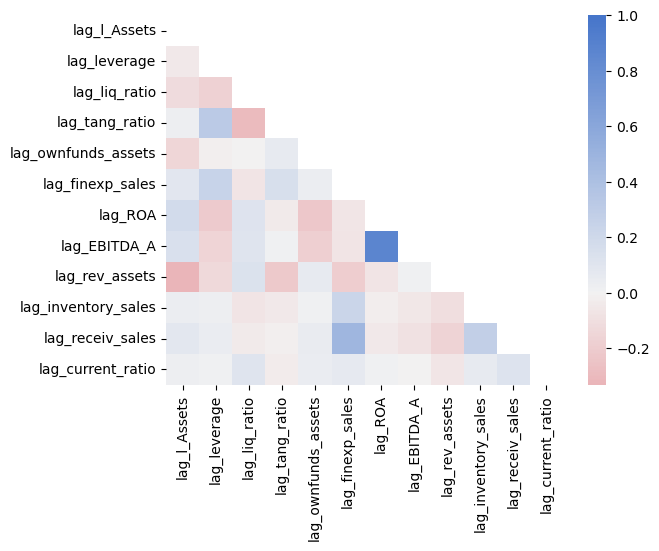

In [14]:
cmap = sns.diverging_palette(10, 255, as_cmap=True) # Create a color map
mask = np.triu(np.ones_like(corr_matrix_vars, dtype=bool)) # Create a mask to only show the lower triangle of the matrix
sns.heatmap(corr_matrix_vars, cmap=cmap, vmax=1, center=0, mask=mask) # Create a heatmap of the correlation matrix (Note: vmax=1 makes sure that the color map goes up to 1 and center=0 are used to center the color map at 0)
plt.show()

Given the very high correlation between `lag_EBITDA_A` and `lag_ROA`, we can keep one and drop the other. Since the paper of Blanco et al. (2023) uses `lag_ROA`, we will keep this variable, though presumably, these two provide the same economic insight since both measure firm profitability.

In [7]:
# X variables, excluding EBITDA_A
Xvars = ['l_Assets', 'leverage', 'liq_ratio', 'tang_ratio',
               'ownfunds_assets', 'finexp_sales', 'ROA',
               'rev_assets', 'inventory_sales', 'receiv_sales', 'current_ratio']

# Feature matrix and target
X = model_df[[f"lag_{v}" for v in Xvars]]
y = model_df['I_overdue']

In [9]:
# Note that the data imported here has been winsorized at the 1% level at the tails.
X.describe().T

,count,mean,std,min,25%,50%,75%,max
lag_l_Assets,4561908.0,6.055573,1.574890,5.988365e-01,5.000922,5.967659,7.008442,10.515090
lag_leverage,4561908.0,0.285213,0.311865,-6.062475e-03,0.026792,0.198089,0.444526,2.472378
lag_liq_ratio,4561908.0,0.156845,0.207051,-3.323733e-01,0.017784,0.076731,0.223881,1.000000
lag_tang_ratio,4561908.0,0.321558,0.284261,0.000000e+00,0.069469,0.243804,0.526066,0.998614
lag_ownfunds_assets,4561908.0,0.128991,0.227177,3.174194e-04,0.014509,0.045407,0.143187,3.270646
lag_finexp_sales,4561908.0,0.038243,0.132982,0.000000e+00,0.002187,0.009427,0.026190,2.540373
lag_ROA,4561908.0,-0.002721,0.218991,-2.763899e+00,-0.009173,0.013125,0.050031,0.713721
lag_rev_assets,4561908.0,1.666260,1.736127,1.422184e-08,0.604697,1.235164,2.116063,14.297154
lag_inventory_sales,4561908.0,0.297142,1.711296,0.000000e+00,0.000000,0.057145,0.221239,71.892097
lag_receiv_sales,4561908.0,0.418142,1.476262,-5.891107e-02,0.059582,0.172535,0.336935,26.490797


## 4. Implementation of Loan Default Prediction Models

### 4.1 Pre-processing

#### 4.1.1 Splitting the Data into Training and Test Sets
Before we can train a machine learning model, we need to split our dataset into a training set and a test set.

We follow Alonso Robisco and Carbó Martínez (2022) and use 80% of the data for training and 20% for testing. We will also set the stratify argument to y to make sure that the distribution of the target variable is the same in the training and test sets. Otherwise, we might randomly not have any defaulted loans in the test set, which would make it impossible to correctly evaluate our model.

We will also standardize the variables.

In [20]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 4.1.2 Scaling Features

To improve the performance of our machine learning model, we should scale the features. 

In [22]:
# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 4.1.3 Evaluation Criertia
We will evaluate the performance of our machine-learning models using the following metrics:

- Accuracy: The proportion of correctly classified instances
- Precision: The proportion of true positive predictions among all positive predictions
- Recall: The proportion of true positive predictions among all actual positive instances
- ROC AUC: The area under the receiver operating characteristic curve

Furthermore, we will plot the ROC curve for each model to visualize the trade-off between the true positive rate and the false positive rate. 

To make the evaluation of our models more convenient, we will define a function that computes these metrics and plots the ROC curve for a given model.

In [24]:
def evaluate_model(clf, X_train, y_train, X_test, y_test, label=''):

    # Compute predictions and probabilities for tha training and test set
    y_pred_train = clf.predict(X_train)
    y_proba_train = clf.predict_proba(X_train)
    y_pred_test = clf.predict(X_test)
    y_proba_test = clf.predict_proba(X_test)

    # Print accuracy measures
    print(f"--------------------------------------------------------------")
    print(f"Metrics: {label}")
    print(f"--------------------------------------------------------------")
    print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train)}")
    print(f"Precision (Train): {precision_score(y_train, y_pred_train)}")
    print(f"Recall (Train): {recall_score(y_train, y_pred_train)}")
    print(f"ROC AUC (Train): {roc_auc_score(y_train, y_proba_train[:, 1])}")
    print(f"--------------------------------------------------------------")
    print(f"Accuracy (Test): {accuracy_score(y_test, y_pred_test)}")
    print(f"Precision (Test): {precision_score(y_test, y_pred_test)}")
    print(f"Recall (Test): {recall_score(y_test, y_pred_test)}")
    print(f"ROC AUC (Test): {roc_auc_score(y_test, y_proba_test[:, 1])}")
    print(f"--------------------------------------------------------------")

    # Compute the ROC curve
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_proba_train[:, 1])
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test[:, 1])

    # Plot the ROC curve
    plt.plot(fpr_train, tpr_train, label = "Train") 
    plt.plot(fpr_test, tpr_test, label = "Test")
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {label}')
    plt.legend()
    plt.show()

### 4.2 Prediction Models

#### **4.2.1 Logistic Regression**

We will use the `LogisticRegression` class from the `sklearn.linear_model` module to train a logistic regression model. We will use the `lbfgs` solver (default) and set the `max_iter` parameter to 5000 to make sure that the optimization algorithm converges. We will also set the `penalty` parameter to None to avoid regularization (e.g. `L1` (lasso) or `L2` (ridge)).

In [26]:
clf_logistic = LogisticRegression(penalty = None, solver = 'lbfgs', max_iter = 5000, class_weight='balanced').fit(X_train_scaled, y_train)

Then evaluate the performance of the logistic regression model

--------------------------------------------------------------
Metrics: Logistic Regression
--------------------------------------------------------------
Accuracy (Train): 0.7089487785537081
Precision (Train): 0.018814325922675866
Recall (Train): 0.6438566225800268
ROC AUC (Train): 0.7270297617642075
--------------------------------------------------------------
Accuracy (Test): 0.7085979337602013
Precision (Test): 0.019005297475031782
Recall (Test): 0.6515015974440894
ROC AUC (Test): 0.7300285475733959
--------------------------------------------------------------


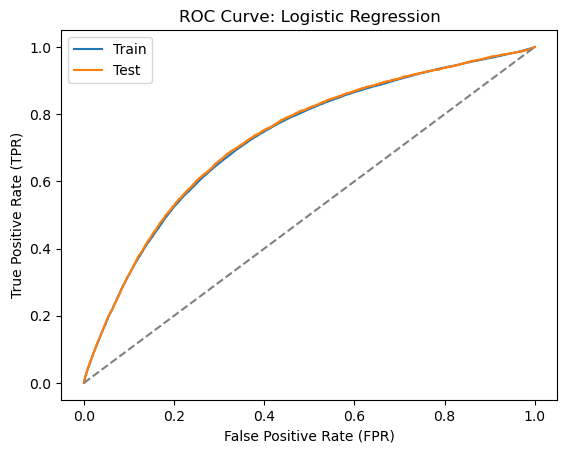

In [28]:
evaluate_model(clf_logistic, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Logistic Regression')

- <span style="color:red"> The logistic regression model performs satisfactorily, with an AUC above 0.70. </span>

#### 4.2.1.1 Plot feature importances

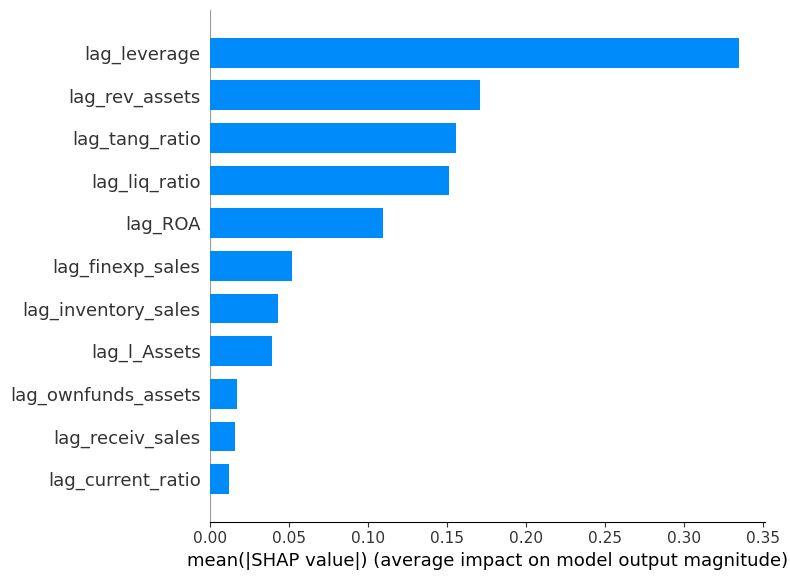

In [31]:
# Fix: use feature names from the original X_train
feature_names = X_train.columns.tolist()

# Use KernelExplainer for logit (because it’s linear)
explainer_logit = shap.Explainer(clf_logistic, X_train_scaled, feature_names=feature_names)
shap_values_logit = explainer_logit(X_test_scaled)

shap.summary_plot(shap_values_logit, X_test_scaled, plot_type="bar", feature_names=feature_names)

#### **4.2.2 Decision Tree**
Let’s now train a decision tree classifier. We will use the `DecisionTreeClassifier` class from the `sklearn.tree` module to train a decision tree classifier. We will set the `max_depth` parameter to 10.

A `DecisionTreeClassifier` is a supervised learning algorithm used for classification tasks. It builds a tree-like model of decisions based on feature values to predict the target label (class).

Think of it like a **flowchart**:
- At each **node**, it asks a yes/no question about a feature.
- Depending on the answer, it goes left or right down the tree.
- Eventually, it reaches a **leaf** node, which contains the predicted class.

In [33]:
clf_tree = DecisionTreeClassifier(max_depth=10, class_weight='balanced').fit(X_train_scaled, y_train)

Then evaluate the performance of the decision tree classifier.

--------------------------------------------------------------
Metrics: Decision Tree
--------------------------------------------------------------
Accuracy (Train): 0.737142028855254
Precision (Train): 0.02388758061288883
Recall (Train): 0.7437224458501054
ROC AUC (Train): 0.8127876525442349
--------------------------------------------------------------
Accuracy (Test): 0.7354178403344214
Precision (Test): 0.021482334334449175
Recall (Test): 0.6700319488817892
ROC AUC (Test): 0.7608904537073786
--------------------------------------------------------------


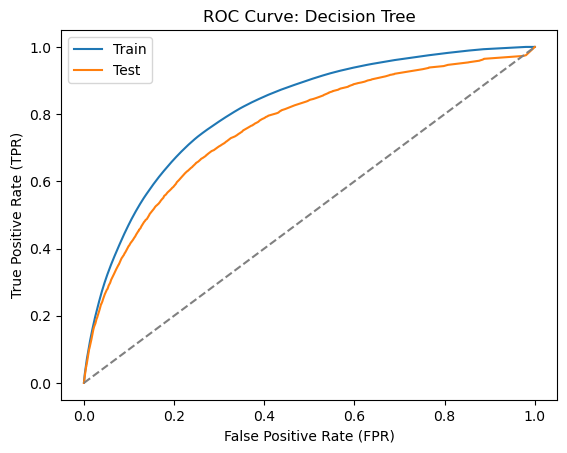

In [35]:
evaluate_model(clf_tree, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Decision Tree')

#### 4.2.2.1 Plot the Decision Tree

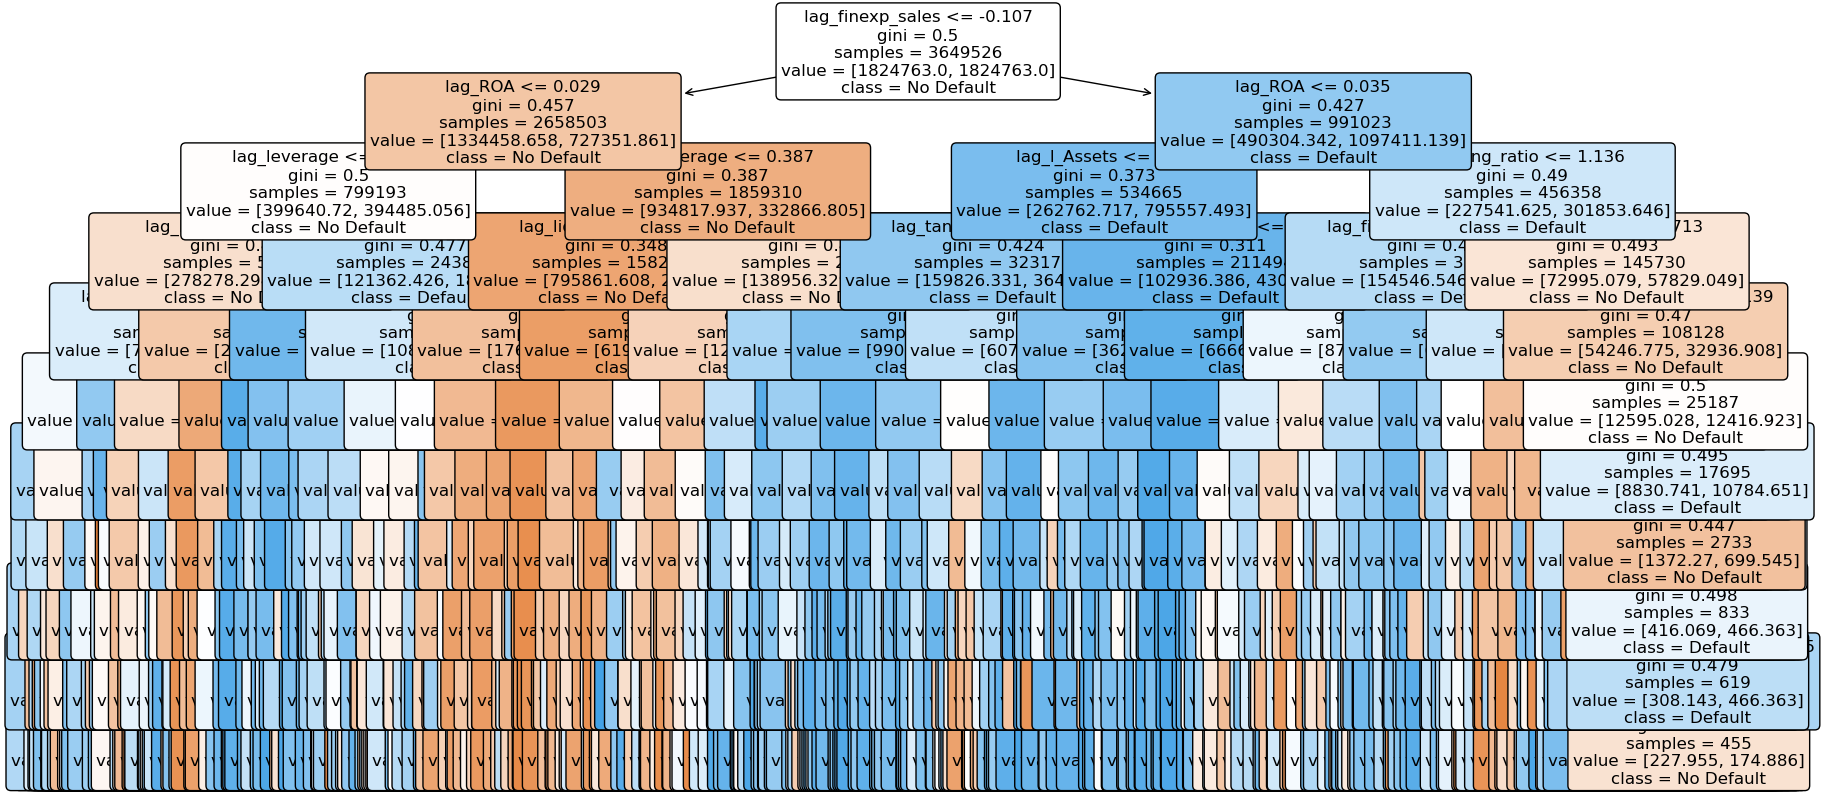

In [37]:
from sklearn.tree import plot_tree

# Plot the tree
plt.figure(figsize=(20,10))  # Adjust size as needed

feature_names = X_train.columns.tolist()  # Convert Index to list

plot_tree(
    clf_tree, 
    feature_names=feature_names,  # if X_train is a DataFrame
    class_names=['No Default', 'Default'],  # adjust to your classes
    filled=True,  # colors nodes by majority class
    rounded=True,  # rounded corners
    fontsize=12
)
plt.show()

#### 4.2.2.2 Extract the Decision Rule as Text

In [120]:
from sklearn.tree import export_text

rules = export_text(clf_tree, feature_names=X_train.columns.tolist())
#print(rules)

#### 4.2.2.3 Plot Feature Importances

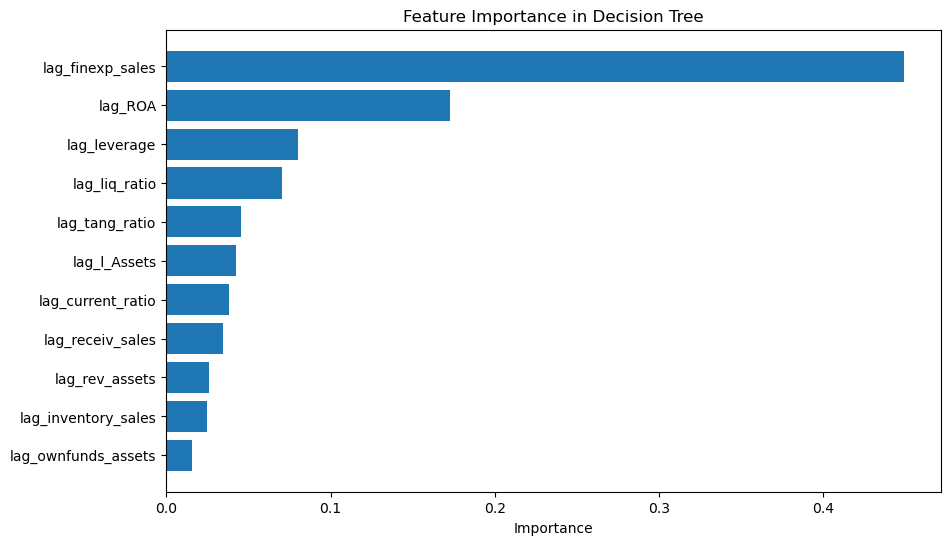

In [41]:
# Get importances and match with feature names
importances = clf_tree.feature_importances_
features = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Most important at the top
plt.show()

#### **4.2.3 Random Forest**

Random Forest is an ensemble learning method that operates by constructing multiple decision trees during training. It combines the output of multiple decision trees to improve predictive accuracy and control overfitting (an issue w/ `DecisionTreeClassfier`).

In a random forest, many decision trees are trained, but each tree receives only a bootstrapped sample of observations (i.e., a random sample of observations with replacement that matches the original number of observations), and each node considers only a subset of features when determining the best split. This forest of randomized decision trees (hence the name) votes to determine the predicted class.

We will use the `RandomForestClassifier` class from the `sklearn.ensemble` module to train a random forest classifier. We will set the `max_depth` parameter to 15 (set a lower `max_depth` for large datasets to ease computational burden) and the `n_estimators` parameter to 100 as in Alonso Robisco and Carbó Martínez (2022).

In [132]:
clf_forest = RandomForestClassifier(
    max_depth=15,
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1  # use all available CPU cores
).fit(X_train_scaled, y_train)

Then, let’s evaluate the performance of the random forest classifier

--------------------------------------------------------------
Metrics: Random Forest
--------------------------------------------------------------
Accuracy (Train): 0.9154161389725679
Precision (Train): 0.07715478212089523
Recall (Train): 0.8084786914574149
ROC AUC (Train): 0.9412567614005403
--------------------------------------------------------------
Accuracy (Test): 0.9099872641064817
Precision (Test): 0.03945851463423705
Recall (Test): 0.4067731629392971
ROC AUC (Test): 0.7866442887417531
--------------------------------------------------------------


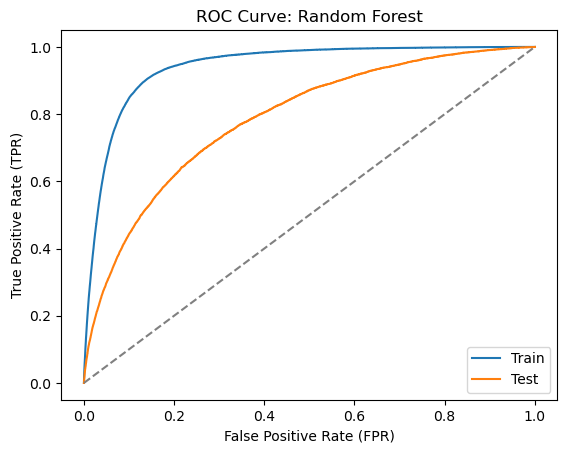

In [134]:
evaluate_model(clf_forest, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Random Forest')

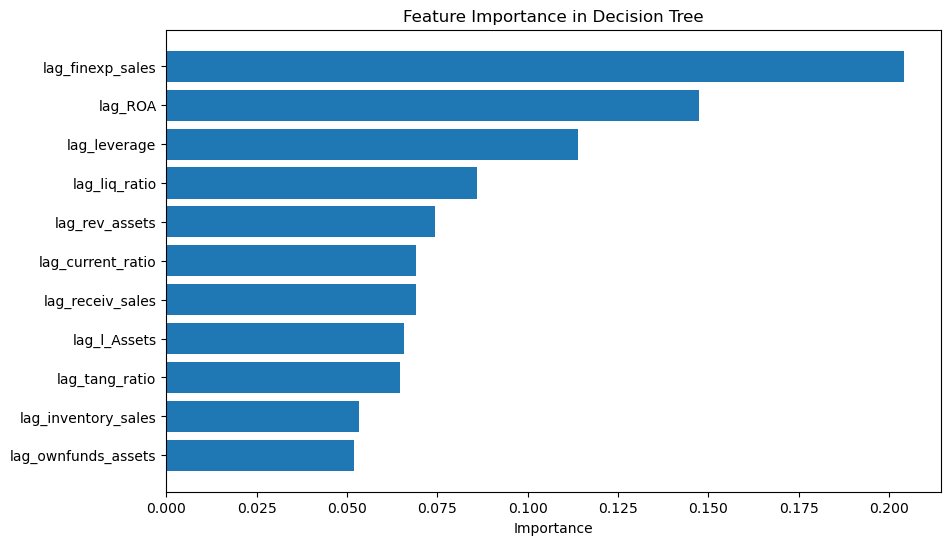

In [137]:
# Get importances and match with feature names
importances_rf = clf_forest.feature_importances_
feature_names = X_train.columns
feature_importance_df_rf = pd.DataFrame({'Feature': features, 'Importance': importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_rf['Feature'], feature_importance_df_rf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Most important at the top
plt.show()

#### **4.2.4 XGBoost**

`XGBoost` (which stands for Extreme Gradient Boosting) is a very popular gradient boosting algorithm in the machine learning space. Though it is not always a tree-based model, it is frequently applied to ensembles of decision trees. Note that `XGBoost` is known for being computationally intensive.

In [97]:
# Calculate class imbalance ratio (only for binary classification: 0 and 1)
pos = sum(y_train == 1)
neg = sum(y_train == 0)
scale_pos_weight = neg / pos

clf_xgb = XGBClassifier(
    max_depth=5,
    n_estimators=40,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # to handle class imbalance (XGBoost does not support the `class_weight` parameter)
    use_label_encoder=False,
    eval_metric='logloss'  # prevent warning
).fit(X_train_scaled, y_train)

/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [18:16:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Then, let’s evaluate the performance of the XGBoost classifier

--------------------------------------------------------------
Metrics: XGBoost
--------------------------------------------------------------
Accuracy (Train): 0.7354338618220558
Precision (Train): 0.02359877493200016
Recall (Train): 0.7392179413456009
ROC AUC (Train): 0.8156861709959011
--------------------------------------------------------------
Accuracy (Test): 0.7349695631873492
Precision (Test): 0.022937276234127404
Recall (Test): 0.7188498402555911
ROC AUC (Test): 0.8003256074997275
--------------------------------------------------------------


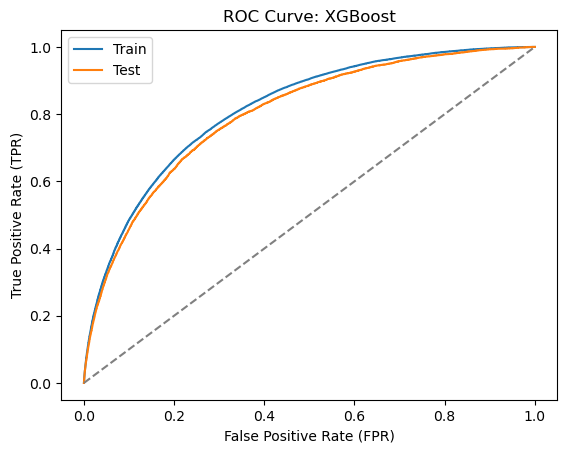

In [99]:
evaluate_model(clf_xgb, X_train_scaled, y_train, X_test_scaled, y_test, label = 'XGBoost')

                Feature  Importance
5      lag_finexp_sales    0.371457
6               lag_ROA    0.166035
1          lag_leverage    0.077398
2         lag_liq_ratio    0.065436
3        lag_tang_ratio    0.063957
8   lag_inventory_sales    0.060073
9      lag_receiv_sales    0.050024
10    lag_current_ratio    0.047941
0          lag_l_Assets    0.040883
7        lag_rev_assets    0.037679
4   lag_ownfunds_assets    0.019117


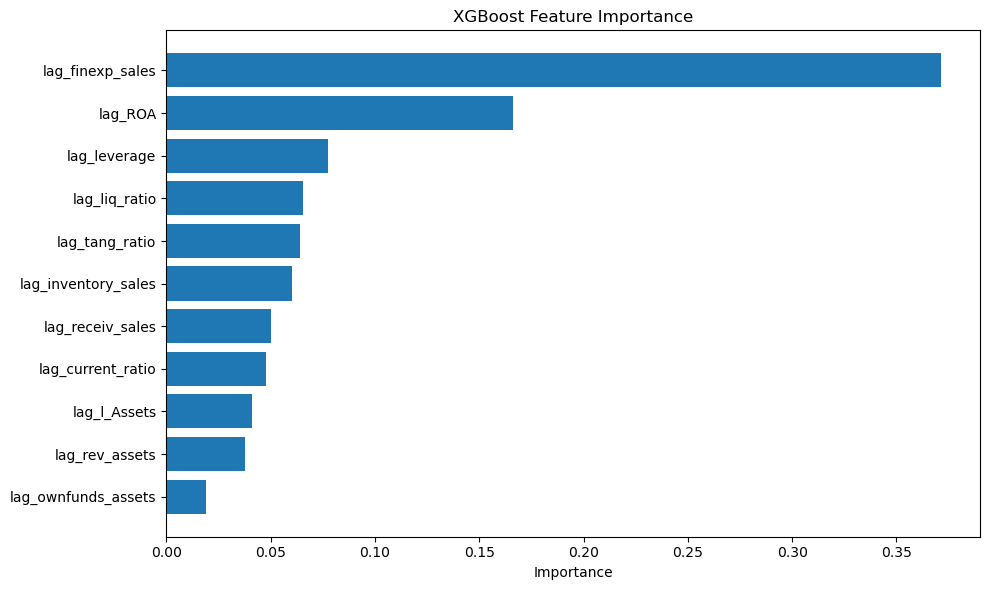

In [101]:
# Get feature importances
importances = clf_xgb.feature_importances_

# Create a DataFrame for easy viewing
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the DataFrame
print(feature_importance_df)

# Optional: Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Overview of the Results

In [130]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'ROC AUC (Train)': [
        roc_auc_score(y_train, clf_logistic.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_tree.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_forest.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_xgb.predict_proba(X_train_scaled)[:, 1])
    ],
    'ROC AUC (Test)': [
        roc_auc_score(y_test, clf_logistic.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_tree.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_forest.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_xgb.predict_proba(X_test_scaled)[:, 1])
    ]
})
results

,Model,ROC AUC (Train),ROC AUC (Test)
0,Logistic Regression,0.727030,0.730029
1,Decision Tree,0.812788,0.760890
2,Random Forest,0.942299,0.786843
3,XGBoost,0.815686,0.800326


#### Get predicted probabilities across all methods

In [162]:
probs_logistic = clf_logistic.predict_proba(X)[:, 1]
probs_tree = clf_tree.predict_proba(X)[:, 1]
probs_forest = clf_forest.predict_proba(X)[:, 1]
probs_xgb = clf_xgb.predict_proba(X)[:, 1]

# Create DataFrame with predicted probs, index aligned with model_df
probs_df = pd.DataFrame({
    'prob_Logistic_Regression': probs_logistic,
    'prob_Decision_Tree': probs_tree,
    'prob_Random_Forest': probs_forest,
    'prob_XGBoost': probs_xgb
}, index=model_df.index)

# Concatenate predicted probabilities as new columns to model_df
# Select only the columns you want from model_df
subset_df = model_df[['firmID', 'year', 'cnae2009Division', 'I_overdue']].reset_index(drop=True)

# Make sure predicted probabilities df has the same index/reset index
probs_df = probs_df.reset_index(drop=True)

# Combine them horizontally (side by side)
final_df = pd.concat([subset_df, probs_df], axis=1)

model_df_with_probs = pd.concat([model_df, probs_df], axis=1)

/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [163]:
model_df_with_probs.head()

,firmID,year,cnae2009Division,firm_size,postal_code,I_overdue,LT_debt_sh,l_age,lag_l_Assets,lag_liq_ratio,...,lag_current_ratio,tag,exclude,housing,NACE_grouped,low_q,prob_Logistic_Regression,prob_Decision_Tree,prob_Random_Forest,prob_XGBoost
0,27.0,2001.0,55.0,Medium,28014.0,0.0,0.805376,4.521789,9.899379,0.051765,...,2.589375,NaN,0.0,0.0,Hospitality & Entertainment,0.0,0.538150,0.615490,0.181902,0.521042
1,27.0,2002.0,55.0,Medium,28014.0,0.0,0.802936,4.532599,10.008686,0.061274,...,2.629214,NaN,0.0,0.0,Hospitality & Entertainment,0.0,0.544532,0.615490,0.176208,0.601227
2,27.0,2003.0,55.0,Medium,28014.0,0.0,0.932781,4.543295,9.988968,0.466521,...,3.187269,NaN,0.0,0.0,Hospitality & Entertainment,0.0,0.511030,0.000000,0.137347,0.480688
3,50.0,2004.0,71.0,Small,28020.0,0.0,1.000000,1.791759,7.400620,0.130727,...,3.773196,NaN,0.0,0.0,Professional & Admin Services,0.0,0.394144,0.752301,0.282308,0.287424
4,50.0,2005.0,71.0,Small,28020.0,0.0,1.000000,1.945910,7.315884,0.085771,...,2.542222,NaN,0.0,0.0,Professional & Admin Services,0.0,0.424609,0.576891,0.278693,0.643851


| Model               | Accuracy Test | Precision Test | Recall Test | ROC AUC Test |
| ------------------- | ------------- | -------------- | ----------- | ------------ |
| Logistic Regression | 0.709         | 0.019          | 0.652       | 0.730        |
| Decision Tree       | 0.735         | 0.021          | 0.670       | 0.761        |
| Random Forest       | 0.910         | 0.039          | 0.407       | 0.787        |
| XGBoost             | 0.735         | 0.023          | 0.719       | 0.800        |


#### Save and export the results

In [166]:
import os

# Path to save
outpath = r"/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/"
filename = "predicted_probabilities.dta"
full_path = os.path.join(outpath, filename)

final_df.to_stata(full_path, write_index=False)

### 4.4. Implementation of Logistic and XGBoost on Full Sample

In [14]:
# --- Train XGBoost on full data ---
# Calculate class imbalance ratio (only for binary classification: 0 and 1)
pos = sum(y == 1)
neg = sum(y == 0)
scale_pos_weight = neg / pos

clf_xgb = XGBClassifier(
    max_depth=5,
    n_estimators=40,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # to handle class imbalance (XGBoost does not support the `class_weight` parameter)
    use_label_encoder=False,
    eval_metric='logloss'  # prevent warning
).fit(X, y)

# Get top 5 XGBoost features
xgb_importances = pd.Series(clf_xgb.feature_importances_, index=X.columns)
top5_xgb = xgb_importances.sort_values(ascending=False).head(5).index.tolist()

# --- Train Logistic Regression on full data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf_logistic = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_logistic.fit(X_scaled, y)

# Get top 5 Logistic Regression features (by absolute value of coefficients)
log_coeffs = pd.Series(clf_logistic.coef_[0], index=X.columns)
top5_logistic = log_coeffs.abs().sort_values(ascending=False).head(5).index.tolist()

/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:48:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [26]:
print(top5_logistic)
print(top5_xgb)

['lag_leverage', 'lag_ROA', 'lag_rev_assets', 'lag_liq_ratio', 'lag_tang_ratio']
['lag_finexp_sales', 'lag_ROA', 'lag_leverage', 'lag_liq_ratio', 'lag_tang_ratio']


#### **Rerun the model using the top5 features**

In [35]:
# --- Retrain Logistic Regression on top 5 ---
scaler_top5 = StandardScaler()
X_scaled_top5 = scaler_top5.fit_transform(X[top5_logistic])
clf_log_top5 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_log_top5.fit(X_scaled_top5, y)

# Predict and AUC
probs_logistic_top5 = clf_log_top5.predict_proba(X_scaled_top5)[:, 1]
auc_logistic_top5 = roc_auc_score(y, probs_logistic_top5)

# --- Retrain XGBoost on top 5 ---
clf_xgb_top5 = XGBClassifier(max_depth=5, n_estimators=40, use_label_encoder=False,
                             scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
clf_xgb_top5.fit(X[top5_xgb], y)

# Predict and AUC
probs_xgb_top5 = clf_xgb_top5.predict_proba(X[top5_xgb])[:, 1]
auc_xgb_top5 = roc_auc_score(y, probs_xgb_top5)

# --- Print results ---
print(f"AUC (Logistic, Top 5): {auc_logistic_top5:.4f}")
print(f"AUC (XGBoost, Top 5): {auc_xgb_top5:.4f}")

/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:16:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AUC (Logistic, Top 5): 0.7186
AUC (XGBoost, Top 5): 0.7895


In [33]:
# Create DataFrame with predicted probs, index aligned with model_df
probs_df_full = pd.DataFrame({
    'prob_Logistic_top5': probs_logistic_top5,
    'prob_XGBoost_top5': probs_xgb_top5
}, index=model_df.index)

# Concatenate predicted probabilities as new columns to model_df
# Select only the columns you want from model_df
subset_df = model_df[['firmID', 'year', 'cnae2009Division', 'I_overdue']].reset_index(drop=True)

# Make sure predicted probabilities df has the same index/reset index
probs_df_full = probs_df_full.reset_index(drop=True)

# Combine them horizontally (side by side)
final_df_full = pd.concat([subset_df, probs_df_full], axis=1)

import os

# Path to save
outpath = r"/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/"
filename = "predicted_prob_top5features.dta"
full_path = os.path.join(outpath, filename)

final_df_full.to_stata(full_path, write_index=False)